# ANOVA-autoapproximation on synthetic data

To this point, when doing an ANOVA-approximation of a synthetic function, it was necessary to use prechosen bandwidths. Now there is a new method provided by the library ```pyANOVAapprox``` that chooses the optimal bandwidths automatically.

In the following notebook, we will explain the ANOVA-approximation, especially the new method ```autoapproximate```, step by step and compare its results to the ones generated with prechosen bandwidths.

### At first, we have to import the necessary libraries.

As we are going to use matrices and vectors, we will need the ```numpy```-library. For other mathematical operations, we also use the ```math```-library.

In [1]:
import numpy as np
import math

For plotting we will need the ```matplotlib.pyplot```-library.

In [2]:
import matplotlib.pyplot as plt

And of course, we can't forget the most important library, that contains all necessary approximation methods: the ```pyANOVAapprox```-library.

In [3]:
import pyANOVAapprox as ANOVAapprox

### Now, we need the data, we can run our tests on.

In this notebook, in contrast to real world datasets, we generate the data ourselves. For that purpose, we will generate nodes and assign each of them a value trough predefined functions. Moreover we will add Gaussian noise to all values, to simulate some kind of randomness like in real world experiments.

As examples, we choose the so called Friedman functions. But many other functions work as well. The first Friedman function is given by
$$f_1 : [0, 1]^{10} \longrightarrow \mathbb{R}, \quad f_1(x) = 10 \cdot \sin{\left( \pi x_1 x_2 \right)} + 20 \cdot \left( x_3 - 0.5 \right)^2 + 10 x_4 + 5 x_5.$$
It has spatial dimension $10$. As one can see, only five of the then variables have an influence on the function.

The second Friedman function is defined as
$$f_2 : [0, 1]^4 \longrightarrow \mathbb{R}, \quad f_2(x) = \sqrt{\left( s_1(x_1) \right)^2 + \left( s_2(x_2) \cdot x_3 - \frac{1}{s_2(x_2) \cdot s_4(x_4)} \right)^2},$$
where we use the scalings
$$s_1(x_1) = 100 x_1, \quad s_2(x_2) = 520 \pi x_2 + 40 \pi, \quad s_4(x_4) = 10 x_4 + 1.$$
In contrast to the first Friedman function, the second Friedman function has only spatial dimension $4$.

The third Friedman function uses the same scalings as the second and is given by
$$f_3 : [0, 1]^4 \longrightarrow \mathbb{R}, \quad f_3(x) = \arctan{\left( \frac{s_2(x_2) \cdot x_3 - \left( s_2(x_2) \cdot s_4(x_4) \right)^{- 1}}{s_1(x_1)} \right)}.$$

It again has spatial dimension $4$.

In the following cell, we write all friedman functions in code to use in Python.

In [4]:
#defining the friedman functions
# scalings
s_1 = lambda x: 100*x
s_2 = lambda x: 520*np.pi*x+40*np.pi
s_4 = lambda x: 10*x+1

# Friedman 1
def friedman1(x):
    #checking if the nodes meet the restraints of our domain
    if np.min(x) < 0 or np.max(x) > 1:
        raise ValueError("The nodes need to be between zero and one.")
    
    return 10*np.sin(np.pi*x[0]*x[1])+20*((x[2]-0.5)**2)+10*x[3]+5*x[4]

# Friedman 2
def friedman2(x):
    #checking if the nodes meet the restraints of our domain
    if np.min(x) < 0 or np.max(x) > 1:
        raise ValueError("The nodes need to be between zero and one.")

    return np.sqrt( (s_1(x[0]))**2 + (s_2(x[1])*x[2] - 1/(s_2(x[1])*s_4(x[3])) )**2 )

# Friedman 3
def friedman3(x):
    #checking if the nodes meet the restraints of our domain
    if np.min(x) < 0 or np.max(x) > 1:
        raise ValueError("The nodes need to be between zero and one.")

    return np.arctan( (s_2(x[1])*x[2] - 1/(s_2(x[1])*s_4(x[3]))) / s_1(x[0]) )

Now, in the following code cell, you can choose, which of the three Friedman functions you want to try. Set ```friedman_number``` equal to the function you chose.

In [5]:
#choose the Friedman function
friedman_number = 1

We will save the spatial dimension of the chosen friedman function for later use.

In [6]:
#save the spatial dimension in a variable
if friedman_number == 1:
    dimensions = 10
else:
    dimensions = 4

Logically, we need some data to train our model with and some data to test it with. As we said in the beginning, we generate the nodes randomly in $[0, 1]^d$ where $d = 10$ for the first and $d = 4$ for the second and third Friedman function.

The following cell lets you decide how many nodes you want for training and how many for testing. Choose two integers greater than zero.

In [56]:
#choose number of data nodes for training
n_train = 50000

#choose number of data nodes for testing
n_test = 3000

With that information, we will now generate our two sets of data nodes for training and for testing.

In [57]:
#generate data_nodes for training

#setting up an empty array with necessary dimension
X_train = np.empty((dimensions,n_train))

#fill the array with random numbers in [0,1]
rng = np.random.default_rng(np.random.randint(1000, 10000))
X_train = rng.random((dimensions, n_train))



#generate data_nodes_test for testing

#setting up an empty array with necessary dimension
X_test = np.empty((dimensions,n_test))

#fill the array with random numbers in [0,1]
rng = np.random.default_rng(np.random.randint(1000, 10000))
X_test = rng.random((dimensions, n_test))

Now, we have our data nodes for training as matrix $X_{\text{train}} \in [0, 1]^{d, n_{\text{train}}}$. Furthermore the data nodes for testing are given by $X_{\text{test}} \in [0, 1]^{d, n_{\text{test}}}$. $d$ is the spatial dimension of the chosen Friedman functions.

In the next step, we create the arrays $y_{\text{train}}$ and $y_{\text{test}}$. Those hold our values, that are assign trough
$$f_j \left( X_{\text{train}} e_i \right)$$
and
$$f_j \left( X_{\text{test}} e_i \right).$$
Here, $e_i \in \mathbb{R}^n$ is the $i$-th standard basis vector of dimension $n$ and $j \in \{ 1, 2, 3 \}$.

In [58]:
#computing data values for training nodes

#creating empty array
y_train = np.empty((1,n_train), dtype = float)

#assigning values
if friedman_number == 1:
    y_train = [friedman1( X_train[:, j] ) for j in range(n_train)]
if friedman_number == 2:
    y_train = [friedman2( X_train[:, j] ) for j in range(n_train)]
else:
    y_train = [friedman3( X_train[:, j] ) for j in range(n_train)]
        


#computing data values for testing nodes

#creating empty array
y_test = np.empty((1,n_test), dtype = float)

#assigning values
if friedman_number == 1:
    y_test = [friedman1( X_test[:, j] ) for j in range(n_test)]
if friedman_number == 2:
    y_test = [friedman2( X_test[:, j] ) for j in range(n_test)]
else:
    y_test = [friedman3( X_test[:, j] ) for j in range(n_test)]

As a last step, we add the Gaussian noise to the data values. As we want to nudge the values randomly but "evenly" up and down, we take zero as the mean. The variance however does not have to bet set to one specific value. The user can try different values himself by setting the variable ```noise_variance``` in the following cell equal to the desired number. If one does not want to set a variance, we will take the same parameters as in [30] and set $\sigma_1 = 1$ for Friedman $1$, $\sigma_2 = 125$ for Friedman $2$ and $\sigma_3 = 0.1$ for Friedman $3$.

In [59]:
#setting the variance
variance = None


#no noise given
if variance == None:
    if friedman_number == 1:
        variance = 1.0
    elif friedman_number == 2:
        variance = 125.0
    else:
        variance = 0.1

If one denotes the Gaussian noise as $\eta_i$ for $i = 1, 2, 3$, then the final data values are given by
$$\left( y_{\text{train}} \right)_i = f_j \left( X_{\text{train}} e_i \right) + \eta_j$$
and
$$\left( y_{\text{test}} \right)_i = f_j \left( X_{\text{test}} e_i \right) + \eta_j.$$

In [60]:
#generating noise

#creating an empty array to hold our noise for the training values
data_noise_train = np.empty((1,n_train))

#generating Gaussian noise
rng = np.random.default_rng(np.random.randint(1000, 10000))
dist = np.random.normal( 0.0, variance)
data_noise_train = rng.normal( 0.0, np.abs(dist), n_train )


#generating noise_test

#creating an empty array to hold our noise for the test values
data_noise_test = np.empty((1,n_test))

#generating Gaussian noise
rng = np.random.default_rng(np.random.randint(1000, 10000))
dist = np.random.normal( 0.0, variance)
data_noise_test = rng.normal( 0.0, np.abs(dist), n_test )

In [61]:
#adding noise to values
y_train = y_train + data_noise_train
y_test = y_test + data_noise_test

### The Approximation Procedure

Until now, we have just "prepared" our data. In the following, we will outline the approximation process.

Consider a function

$$f \in L_2 \left( D^d \right) := \left\{ f : D^d \longrightarrow \mathbb{K} : ||f||_{L_2 \left( D^d \right)} := \sqrt{\int_{D^d} |f(x)|^2 \ \text{d}x} < \infty \right\}$$

where $d \in \mathbb{N}$ is the so called spatial dimension. We set $D = \mathbb{T}$, which we identify by the interval $[- 0.5, 0.5)$, if $f$ is $1$-periodic and $D = [0,1]$ if $f$ is non-periodic. In the non-periodic case we will assume $\mathbb{K} = \mathbb{R}$ while in the periodic case $\mathbb{K} = \mathbb{C}$ is allowed. Furthermore, we use the conventional scalar product
$$\langle f, g \rangle := \int_{D^d} f(x) \overline{g(x)} \ \text{d}x$$
between two functions $f, g \in L_2 \left( D^d \right)$.

For any given real world data, we assume that behind the data is a function $f \in L_2 \left( D^d \right)$. Knowing that function can give us crucial information for creating predictions based on former observations. But normally we don't know this function and/ or it can't be determined exactly. For that reason we at least try to get an approximation function which we can then use to build a good model according to the data.

We assume that our data follows a function $f \in L_2 \left( D^d \right)$. We are hence interested in a function $\tilde{f}$ with
$$\tilde{f}(x) \approx f(x).$$

Now, consider a complete orthonormal system $\{ \phi_{\mathbf{k}} \}_{\mathbf{k} \in \mathbb{Z}^d}$ with tensor product structure, meaning that we have a complete orthonormal system $\{ \eta_k \}_{k \in \mathbb{Z}}$ in $L_2 (D)$ and
$$\phi_{\mathbf{k}} = \prod_{i = 1}^d \eta_{k_i}(x_i).$$
Since $L_2 \left( D^d \right)$ together with the scalar product given above forms a Hilbert space, an $f \in L_2 \left( D^d \right)$ can be written as
$$f(x) = \sum_{\mathbf{k} \in \mathbb{Z}^d} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}}(x)$$
with $c_{\mathbf{k}}(f) = \langle f, \phi_{\mathbf{k}} \rangle$. Parseval's identity would also yield
$$||f||_{L_2 \left( D^d \right)}^2 = \sum_{\mathbf{k} \in \mathbb{Z}^d} |c_{\mathbf{k}}(f)|^2.$$

If we now set $\mathcal{D} = \{ 1, 2, \ldots, d \}$, then we know by the classical ANOVA decomposition that $f$ can be uniquely decomposed as
$$f(x) = \sum_{\mathbf{u} \subseteq \mathcal{D}} f_{\mathbf{u}}(x)$$
where
$$f_{\mathbf{u}} = f_{\mathbf{u}}(x_{\mathbf{u}}) := \underset{\text{supp} \ \mathbf{k} = \mathbf{u}}{\sum_{\mathbf{k} \in \mathbb{Z}^d}} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}}(x).$$
We call $f_{\mathbf{u}}$ an ANOVA term and identify $\text{supp} \ \mathbf{k} := \{ s \in \mathcal{D} : k_s \neq 0 \}$.

Note that we have $|\mathcal{P}(\mathcal{D})| = 2^d$ summands in $\sum_{\mathbf{u} \subseteq \mathcal{D}} f_{\mathbf{u}}(x)$. This means, the number of terms grows exponentially in $d$ showing an expression of the curse of dimensionality in the decomposition. To improve efficiency in the approximation we will somehow need to limit the number of summands. So as a workaround we only take subsets of ANOVA terms $U \subseteq \mathcal{P}(\mathcal{D})$ into account.

So how do we get such a $U \subseteq \mathcal{P}(\mathcal{D})$ to start with? At the beginning, we don't know anything about the function and its behaviour. So there are not many possibilities to choose our $U$. We will proceed by setting a so called superposition threshold $d_s \in \mathcal{D}$ with $d_s < d$. By default, we set
$$d_s = 2$$
but the user can choose another $d_s$. So in the following cell, you set a $d_s$. Write ```None```, if you don't want to set a special $d_s$.

In [62]:
#choose ds here
ds = 2


#if no ds is provided we will proceed with ds = 2
if ds == None:
    ds = 2

Now, with our $d_s$ set, we define
$$U_{d_s} := \{ \mathbf{u} \subseteq \mathcal{D} : |\mathbf{u}| \leq d_s \}$$
and choose this set $U_{d_s}$ as our initial $U$. This cuts off all the higher-dimensional interactions and leaves us with only the lower-dimensional ones. In the most cases, we get a really good approximation and the error is minimal.
By that procedure, we not longer sum over all $\mathbf{u} \subseteq \mathcal{D}$ but only those sets in $U_{d_s}$. So we assume
$$f(x) \approx \sum_{\mathbf{u} \in U_{d_s}} f_{\mathbf{u}} (x) = \sum_{\mathbf{u} \in U_{d_s}} \underset{\text{supp} \ \mathbf{k} = \mathbf{u}}{\sum_{\mathbf{k} \in \mathbb{Z}^d}} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}}(x)$$
by the definition of the ANOVA terms. You notice quickly, that limiting ourselves to $U_{d_s} \subseteq \mathcal{D}$ has reduced the number of summands of the outer sum, but we still have infinitely many summands for every $\mathbf{u} \in U_{d_s} \setminus \emptyset$ in the inner sum.

As a consequence, we have to limit ourselves to finitely many terms in the inner sum. We do that by choosing only a finite subset
$$P_{\mathbf{u}} I_{\mathbf{u}} \subseteq \left\{ \mathbf{k} \in \mathbb{Z}^d : \text{supp} \ \mathbf{k} = \mathbf{u} \right\}$$
for every $\mathbf{u} \in U_{d_s}$. For that choose $I_{\mathbf{u}} \subseteq \left( \mathbb{Z} \setminus \{ \mathbf{0} \} \right)^{|\mathbf{u}|}$. Then
$$P_{\mathbf{u}} I_{\mathbf{u}} := \{ \mathbf{k} \in \mathbb{Z}^d : \mathbf{k}_{\mathbf{u}} \in I_{\mathbf{U}}, \mathbf{k}_{\mathbf{u}^C} = \mathbf{0} \}$$
is a set that fulfills the conditions.

So now we have
$$f(x) \approx \sum_{\mathbf{u} \in U_{d_s}} \sum_{\mathbf{k} \in P_{\mathbf{u}} I_{\mathbf{u}}} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}}(x).$$
As both sums are finite we can also write
$$f(x) \approx \sum_{\mathbf{k} \in I (U)} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}}(x)$$
where $I(U)$ is the union
$$I(U) = \bigcup_{\mathbf{u} \in U_{d_s}} I_{\mathbf{u}}.$$

So how do we choose thoose sets $I_{\mathbf{u}}$? We do that by taking an even parameter $N_{u} \in 2 \mathbb{N}$ and setting
$$I_{\mathbf{u}}^{\text{per}} = \left\{ - \frac{N_{\mathbf{u}}}{2}, \ldots, - 1, 1, \ldots, \frac{N_{\mathbf{u}}}{2} - 1 \right\}$$
if $f$ is periodic and
$$I_{\mathbf{u}}^{\text{non-per}} = \{ 1, 2, \ldots, N_{\mathbf{u}} - 1 \}$$
if $f$ is non-periodic. But now we run into the problem of selecting a suitable $N_{\mathbf{u}}$.

In theory, you could choose that $N_{\mathbf{u}}$ for every $u \in U_{d_s}$ separately, but we will set one $N_{\mathbf{u}}$ for all $u \in U_{d_s}$ with $|u| = 1$, one $N_{\mathbf{u}}$ for all $u \in U_{d_s}$ with $|u| = 2$ and so on. We will call those $N_{\mathbf{u}}$ the bandwidth.

In the following cell you can set those bandwidths by hand. Therefore write a list with length $d_s$ which you put the bandwidths in, e.g. the at the $i$-th Index, you put the bandwidth $N_{\mathbf{u}}$ for all $u \in U_{d_s}$ with $|u| = i + 1$. Keep in mind, that those bandwidths have to be even numbers greater than zero.
If you don't want to set any bandwidths by hand, leave the list empty. We will then choose the bandwidths, according to
$$N_{\mathbf{u}} = 2 \cdot \left\lfloor \frac{b^{\frac{1}{|u|}}}{2} \right\rfloor$$
where
$$b := \frac{M}{\log_{10} \left( M \right) \cdot n_{num}},$$
where $M$ denotes the number of rows of $y_{\text{train}}$, e.g. $y_{\text{train}} \in \mathbb{R}^M$ and
$$n_{num} := \sum_{k = 1}^{d_s + 1} \binom{6}{k}.$$

In [63]:
#put your desired bandwidths into the following list, e.g. bw = [ 6, 4, 2 ] for ds = 2
#if you don't want to set specific bandwidths yourself, leave the list empty

bw = [ 4, 2]



#calcutating initial bandwidth, if no bandwidths are given
M = len(y_train)
if bw == []:
    num = np.sum([math.comb(6, k) for k in np.arange(1, ds + 1)])
    b = M / (math.log10(M) * num)
    for a in range(ds):
        bw.append(math.floor(np.power(b, 1/(a + 1))/2) * 2)

As we now have a finite sum, we can finally look for a way to determine the coefficients in
$$f(x) \approx \sum_{\mathbf{k} \in I (U)} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}}(x).$$
From the assumption, that our $f$ should approximate our data, we get that
$$\left( y_{\text{train}} \right)_i = \sum_{\mathbf{k} \in I (U)} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}} \left( X_{\bullet, i} \right).$$
This motivates to write the equations rowwise underneath each other to get
$$\left( y_{\text{train}} \right)_1 = \sum_{\mathbf{k} \in I (U)} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}} \left( X_{\bullet, 1} \right)$$
$$\vdots$$
$$\left( y_{\text{train}} \right)_M = \sum_{\mathbf{k} \in I (U)} c_{\mathbf{k}}(f) \cdot \phi_{\mathbf{k}} \left( X_{\bullet, M} \right).$$
As the coefficients are the same in every equation, we can write this system of equations in the classic matrix form:
$$\mathbf{y} := y_{\text{train}} = \begin{bmatrix}
\phi_{\emptyset}(X_{\bullet,1}) & \cdots & \phi_{\mathbf{k}}(X_{\bullet,1}) & \cdots \\
\vdots & & \vdots & \\
\phi_{\emptyset}(X_{\bullet,M}) & \cdots & \phi_{\mathbf{k}}(X_{\bullet,M}) & \cdots \\
\end{bmatrix} \cdot
\begin{bmatrix}
c_{\emptyset} \\ \vdots \\ c_{\mathbf{k}} \\ \vdots
\end{bmatrix}.$$
By defining
$$\mathbf{F}(X, I(u)) := \left( \phi_{\mathbf{k}}(X_{\bullet, i}) \right)_{k \in I(U), i \in \{ 1, \ldots, M \}}$$
we can rewrite our linear equation as
$$0 \overset{!}{=} \mathbf{y} - \mathbf{F}(X, I(U)) \hat{\mathbf{f}}$$
where $\hat{\mathbf{f}}$ holds our coefficients that are to be determined. Now in the most cases, we can't solve that system directly, as $\mathbf{F}(X, I(u))$ won't be a square matrix and even then we don't know if it is invertible. So instead we determine the coefficients by solving the least-squares problem:
$$\hat{\mathbf{f}} = \left( \hat{f}_{\mathbf{k}} \right)_{\mathbf{k} \in I(U)} = \underset{\hat{\mathbf{g}} \in \mathbb{K}^{|I(U)|}}{\arg \min} \left| \left| \mathbf{y} - \mathbf{F}(X, I(U)) \hat{\mathbf{g}} \right| \right|_2^2.$$

If $\mathbf{F}(X, I(u))$ has full rank, the problem at least has a unique solution and $\hat{f}_{\mathbf{k}} \approx c_{\mathbf{k}}(f)$. If the oversampling is large enough, meaning that $M > |I(U)|$, e.g. we have much more columns than rows, we will assume full rank for $\mathbf{F}(X, I(u))$. For an arbitrary chosen $x \in D^d$, we then get our approximation trough
$$f(x) \approx S(X, I(U)) f(x) = \sum_{\mathbf{k} \in I(U)} \hat{f}_{\mathbf{k}} \cdot \phi_{\mathbf{k}}(x).$$

To solve the least-squares problem efficiently, we are going to use the iterative LSQR solver. As the LSQR solver needs to multiply with $\mathbf{F}(X, I(u))$, its adjoint $\mathbf{F}^*(X, I(u))$ in the periodic case and its transposed $\left( \mathbf{F}(X, I(u)) \right)^T$ in the non-periodic case, we provide it with a method for fast matrix multiplication. This method is based of the idea of Grouped Transformation which itself is based on the NFFT or the NFCT. As the grouped transformations provide oracle functions for the multiplications, we can even use the matrix-free variant of LSQR and don't need to construct $\mathbf{F}(X, I(u))$ explicitly.

Now it is possible for $\mathbf{F}(X, I(u))$ to not have full rank, especially if $|I(U)| > M$, e.g. we have more rows than columns. In this case we can add $l_2$ or $\textit{Tikhonov}$ regularization. We then solve the modified least-squares problem:
$$\underset{\hat{\mathbf{g}} \in \mathbb{K}^{|I(U)|}}{\arg \min} \left[ \left| \left| \mathbf{y} - \mathbf{F}(X, I(u)) \hat{\mathbf{g}} \right| \right|_2^2 + \lambda \left| \left| \hat{\mathbf{g}} \right| \right|_2^2 \right],$$
by introducing a regularization parameter $\lambda > 0$. Notice that by setting $\lambda = 0$ we would get our original problem back. Furthermore we get
\begin{align*}
\left| \left| \mathbf{y} - \mathbf{F}(X, I(u)) \hat{\mathbf{g}} \right| \right|_2^2 + \lambda \left| \left| \hat{\mathbf{g}} \right| \right|_2^2 &= \left\langle \mathbf{y} - \mathbf{F}(X, I(u)) \hat{\mathbf{g}}, \mathbf{y} - \mathbf{F}(X, I(u)) \hat{\mathbf{g}} \right\rangle + \left\langle \sqrt{\lambda} \hat{\mathbf{g}}, \sqrt{\lambda} \hat{\mathbf{g}} \right\rangle \\
&= \left\langle \begin{bmatrix}
\mathbf{y} - \mathbf{F}(X, I(u)) \hat{\mathbf{g}} \\ \sqrt{\lambda} \hat{\mathbf{g}}
\end{bmatrix}, \begin{bmatrix}
\mathbf{y} - \mathbf{F}(X, I(u)) \hat{\mathbf{g}} \\ \sqrt{\lambda} \hat{\mathbf{g}}
\end{bmatrix} \right\rangle \\
&= \left| \left| \begin{pmatrix}
\mathbf{y} \\ \mathbf{0}
\end{pmatrix} - \begin{pmatrix}
\mathbf{F}(X, I(u)) \\ \sqrt{\lambda} \mathbf{I}
\end{pmatrix} \hat{\mathbf{g}} \right| \right|_2^2,
\end{align*}
where $\mathbf{0}$ is the zero vector $\in \mathbb{R}^{|I(U)|}$ and $I$ is the identity matrix $\in \mathbb{R}^{|I(U)| \times |I(U)|}$. So as a consequence, we can use the LSQR solver for the modified problem too. As
$$\begin{pmatrix}
\mathbf{F}(X, I(u)) \\ \sqrt{\lambda} \mathbf{I}
\end{pmatrix} \in \mathbb{K}^{(M + |I(U)|) \times |I(U)|}$$
the matrix has more rows than columns. It follows that, if this matrix has full column rank, we again get a unique solution from solving the least-squares problem.

In the following code cell, you can type in a list of finitely many $\lambda$ for which the least-squares problem should be solved. As we test our model afterwards we will automatically choose the lambda, which gives the model with the least error. If you don't want to set any $\lambda$ leave the list empty. The least-squares problem will only be solved for $\lambda = 0$, e.g. the case without regularization.

In [64]:
#choose the lambdas for regularization, e.g. lambdas = [ 0.5, 1.0, 2.0 ]
lambdas = [ 0.0 ]



#setting the list, if no lambda is given
if lambdas == []:
    lambdas = [ 0.0 ]

Now before we can solve the least-squares problem, we need to choose our basis, e.g. the orthonormal system $\{ \phi_{\mathbf{k}} \}_{\mathbf{k} \in \mathbb{Z}^d}$. For that you have to select one of the following bases:

1. **The Fourier System (per):**
$$\phi_{\mathbf{k}}^{\text{exp}}(x) = \text{e}^{2 \pi i \mathbf{k} \cdot x}$$
for periodic functions,

2. **The cosine system (cos):**
$$\phi_{\mathbf{k}}^{\text{exp}}(x) = \sqrt{2}^{| \text{supp} \ \mathbf{k} |} \prod_{s \in \text{supp} \ \mathbf{k}} \cos{ \left( \pi k_s x_s \right)}$$
for non-periodic functions,

3. **The Chebyshev system (cheb):**
$$\phi_{\mathbf{k}}^{\text{exp}}(x) = \sqrt{2}^{| \text{supp} \ \mathbf{k} |} \prod_{s \in \text{supp} \ \mathbf{k}} \cos{ \left( k_s \arccos{ \left( 2 x_s - 1 \right)} \right)}$$
for non-periodic functions.

In the following code cell, you can determine, which bases you want to use by writing the abbreviation given above in quotation marks, e.g. ```basis = "cos"``` for the cosine system. If you don't want to choose a basis, write ```None```. Then the cosine basis is used.

In the case of the Fourier basis, the nodes need to be between $- 0.5$ and $0.5$. In the case of the cosine or Chebyshev basis, the nodes need to be between $0$ and $1$. Depending on the choice of the basis the nodes are automatically scaled.

In [65]:
#write the abbreviation of the basis you want to use in quotation marks, e.g. as a string of letters
basis = None





#choose basis if None is given
if basis == None:
    basis = "cos"





#scaling of the nodes
max = np.max([np.max(X_train), np.max(X_test)])
min = np.min([np.min(X_train), np.min(X_test)])
if min < 0 or max > 1:
    X_train = (X_train - min) / (max - min)
    X_test = (X_test - min) / (max - min)
if basis == "per":
    X_train /= 4
    X_test /= 4

Now we can initiate the process, meaning that we compute the coefficients $c_{\mathbf{k}}(f)$ by taking the training the training data as the input.

In [66]:
#approximation
ads = ANOVAapprox.approx(np.transpose(X_train), y_train, lam = lambdas, ds = ds, N = bw, basis = basis)
ANOVAapprox.approx.approximate(ads)

Trough this approximation we have gained crucial information about our $f$. We want to use that information to improve our $U$ and run the whole approximation again.

So at first we want to somehow "measure the influence/ importance" of each $\mathbf{u} \in U$. Therefore, we define the variance of $f$ as
$$\sigma^2(f) := \left| \left| f \right| \right|_{L_2 \left( D^d \right)}^2 - |c_{\mathbf{0}}(f)|^2 = \sum_{\mathbf{k} \in \mathbb{Z}^d \setminus \{ 0 \}} |c_{\mathbf{k}}(f)|^2.$$
Notice that for every $u \in U$ the ANOVA terms $f_{\mathbf{u}}$ are functions $\in L_2 \left( D^d \right)$ as well so we can take their variance as
$$\sigma^2(f_{\mathbf{u}}) = \left| \left| f_{\mathbf{u}} \right| \right|_{L_2 \left( D^d \right)}^2.$$
The constant term $|c_{\mathbf{0}}(f_{\mathbf{u}})|$ vanishes as it is equal to zero by definition.

The relative importance of each $\mathbf{u} \in U$ is now measured through global sensitity indices (GSIs), defined as
$$\rho(\mathbf{u}, f) := \frac{\sigma^2(f_{\mathbf{u}})}{\sigma^2(f)}.$$
By definition we have $\rho(\mathbf{u}, f) \in [0,1]$. As we have only approximated the coefficients, we will use the GSIs given by the approximation, e.g. $\rho(\mathbf{u}, S(X, I(U)) f)$.

Now we are also interested in how much influence one variable $i \in \mathcal{D}$ has to the variance of the function. We achieve this by considering all terms $\mathbf{u} \in U$ with $i \in \mathbf{u}$ and summing their GSIs:
$$\sum_{\mathbf{u} \in \{ \mathbf{v} \in U : i \in \mathbf{v} \}} \rho(\mathbf{u}, S(X, I(U)) f).$$
It can happen that a variable seems important if it occurs in many rather unimportant terms of the same cardinality in contrast to other variables with some terms of that order not appearing in $U$. Therefore, we divide each summand by the amount of subsets of $U_{d_s}$ with $i$ in it and the same cardinality as the current $\mathbf{u}$:
$$\sum_{\mathbf{u} \in \{ \mathbf{v} \in U : i \in \mathbf{v} \}} \frac{\rho(\mathbf{u}, S(X, I(U)) f)}{\left| \left\{ \mathbf{v} \in U : |\mathbf{u}| = |\mathbf{v}|, i \in \mathbf{v} \right\} \right|}.$$
We could already take that as our attribute ranking, but we choose to divide by a certain normalization to achieve $\sum_{i \in \mathcal{D}} r(i) = 1$, where
$$r(i) = \frac{\sum_{\mathbf{u} \in \{ \mathbf{v} \in U : i \in \mathbf{v} \}} \frac{\rho(\mathbf{u}, S(X, I(U)) f)}{\left| \left\{ \mathbf{v} \in U : |\mathbf{u}| = |\mathbf{v}|, i \in \mathbf{v} \right\} \right|}}{\sum_{\mathbf{u} \in U} \left( \sum_{i \in \mathbf{u}} \frac{1}{\left| \left\{ \mathbf{v} \in U : |\mathbf{u}| = |\mathbf{v}|, i \in \mathbf{v} \right\} \right|} \right) \rho(\mathbf{u}, S(X, I(U)) f)}.$$

In the following two diagrams, we will plot the attribute ranking $r(i)$ for each $i \in \mathcal{D}$ and then the GSIs for every $\mathbf{u} \in U_{d_s}$. For better comparison, we plot the attribute ranking and the GSIs for every regularization parameter $\lambda$ into the same diagram, if there are five or fewer $\lambda$ given. If more are given, we will plot the attribute ranking and gsis for each $\lambda$ in a different diagramm.

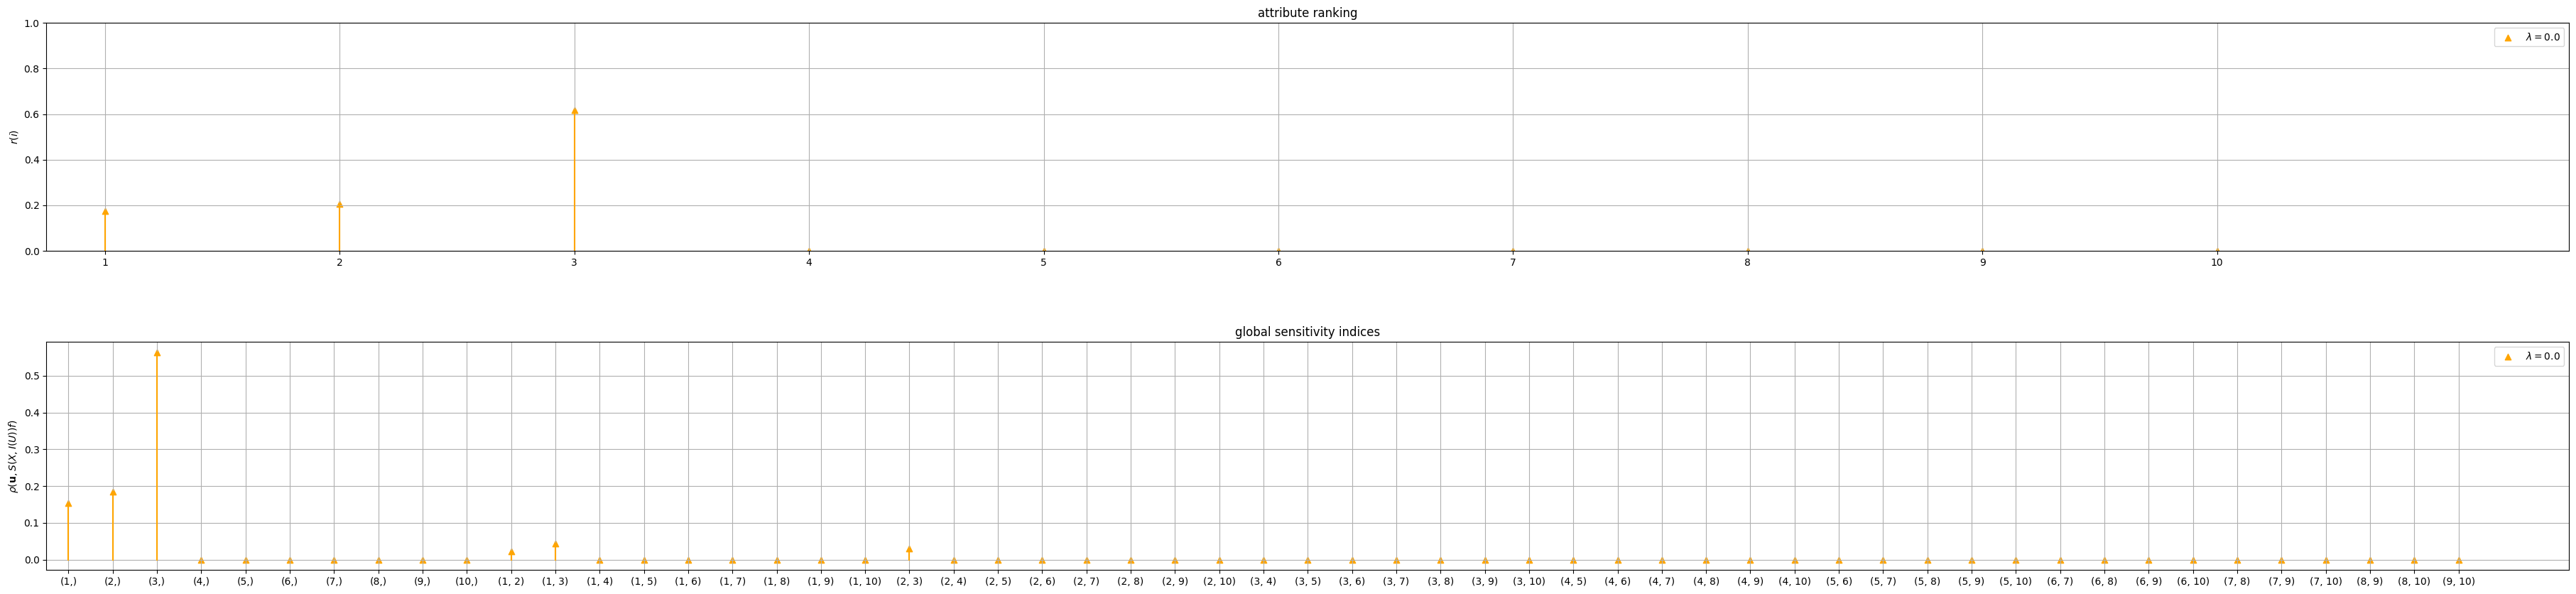

In [67]:
ri = ads.get_AttributeRanking()
gsis = ads.get_GSI()


if len(lambdas) <= 5:
    colors = [ "orange", "green", "red", "blue", "purple" ]

    #creating raw plot
    fig, (ax1, ax2) = plt.subplots(2,1)



    #plotting attribute ranking
    #array for xaxis
    xaxis = np.arange(1, dimensions + 1, 1)

    #plotting the attribute ranking
    for l in range(len(lambdas)):
        ax1.scatter(xaxis + 0.15*l, ri[lambdas[l]], c = colors[l], marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in range(len(xaxis)):
            ax1.plot([i + 1 + 0.15*l,i + 1 + 0.15*l],[0,ri[lambdas[l]][i]], c = colors[l])
    
    ax1.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
    ax1.set_xticklabels(xaxis)
    ax1.set_ylabel("$r(i)$")
    ax1.set_title("attribute ranking")
    ax1.set_xlim(0.75, len(ri[lambdas[0]]) + 1.5)
    ax1.set_ylim(0, 1)
    ax1.legend()
    ax1.grid()




    #plotting gsis
    #array for xaxis
    xaxis = np.arange(0, len(gsis[lambdas[0]]),1)

    #plotting the gsis
    for l in range(len(lambdas)):
        ax2.scatter(xaxis + 0.15*l, gsis[lambdas[l]], c = colors[l], marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in range(len(xaxis)):
            ax2.plot([i + 0.15*l,i + 0.15*l],[0,gsis[lambdas[l]][i]], c = colors[l])
    
    ax2.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
    ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
    ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
    ax2.set_title("global sensitivity indices")
    ax2.set_xlim(-0.5, len(gsis[lambdas[0]]) + 1.5)
    ax2.legend()
    ax2.grid()
    

    fig.set_figwidth(xaxis.shape[0]/1.2)
    fig.set_figheight(10)
    fig.subplots_adjust(hspace=0.4)
    plt.show()
else:
    for l in range(len(lambdas)):
        color = colors[l % 5]
        #creating raw plot
        fig, (ax1, ax2) = plt.subplots(2,1)

        #plotting attribute ranking
        #array for xaxis
        xaxis = np.arange(1, dimension + 1, 1)

        #plotting attribute ranking
        ax1.scatter(xaxis, ri[lambdas[l]], c = color, marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in xaxis:
            ax1.plot([i,i],[0,ri[lambdas[l]][i - 1]], c = color)
        ax1.set_xticks(xaxis)
        ax1.set_ylabel("$r(i)$")
        ax1.set_title("attribute ranking  $( \\lambda = $" + str(lambdas[l]) + "$)$")
        ax1.legend()
        ax1.grid()

        #plotting gsis
        #array for xaxis
        xaxis = np.arange(0, len(gsis[lambdas[0]]),1)

        #plotting gsis
        ax2.scatter(xaxis, gsis[lambdas[l]], c = color, marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in xaxis:
            ax2.plot([i,i],[0,gsis[lambdas[l]][i]], c = color)
        
        
        
        ax2.set_xticks(xaxis)
        ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
        ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
        ax2.set_title("global sensitivity indices  $( \\lambda = $" + str(lambdas[l]) + "$)$")
        ax2.legend()
        ax2.grid()

        
        fig.set_figwidth(xaxis.shape[0]/1.2)
        fig.subplots_adjust(hspace=0.4)
        plt.show()

At this point, we want to get rid of unimportant terms, meaning subsets $\mathbf{u} \in U_{d_s}$ that have little to no influence on the variance of the function.

So at first, we focus on the attribute ranking. There is the option to remove some $i \in \mathcal{D}$ entirely, if they do not contribute much to the function. For that, you can either write the $i \in \mathcal{D}$ you want to remove down below or set an $\varepsilon > 0$ that cuts off all indices $i \in \mathcal{D}$ with $r(i) < \varepsilon$. The approximation is repeated afterwards with the chosen dimensions removed, e.g. if you remove $i \in \mathcal{D}$, then the data nodes will be reduced to
$$x = (x_1, \ldots, x_{i - 1}, x_{i + 1}, \ldots, x_{|\mathcal{D}|}) \in \mathcal{D}^{d - 1}.$$
The $d_s$, prechosen bandwidths, lambdas and basis will be kept.

So in the following code cell write down the indices $i \in \mathcal{D}$ you want to remove as a list, e.g. ```dr = [ 1, 3]``` or, if you want to choose an $\varepsilon$ for cutoff, set ```dr = epsilon```, e.g. ```dr = 0.1```. If you don't want to remove any indices, set ```dr = None```. We will then proceed by keeping all indices.

In [68]:
#cutoff indices
dr = None


if dr != None:
    dimension = len(ri[lambdas[0]])
    if type(dr) == float or type(dr) == int:
        epsilon = dr
        dr = []
        for i in range(dimension):
            if np.min([ri[l][i] for l in lambdas]) < epsilon:
                dr.append(i + 1)

        #plotting attribute ranking again to visualize cutoff
        if len(lambdas) <= 5:
            colors = [ "orange", "green", "red", "blue", "purple" ]
        
            #creating raw plot
            fig, ax1 = plt.subplots(1,1)
        
            #plotting attribute ranking
            #array for xaxis
            xaxis = np.arange(1, dimensions + 1, 1)
        
            #plotting the attribute ranking
            for l in range(len(lambdas)):
                ax1.scatter(xaxis + 0.15*l, ri[lambdas[l]], c = colors[l], marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
                for i in range(len(xaxis)):
                    ax1.plot([i + 1 + 0.15*l,i + 1 + 0.15*l],[0,ri[lambdas[l]][i]], c = colors[l])
            ax1.plot([0.75, len(ri[lambdas[0]]) + 1.5], [epsilon, epsilon], color = "black", linestyle = "--", label = "$\\varepsilon$")
            ax1.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
            ax1.set_xticklabels(xaxis)
            ax1.set_ylabel("$r(i)$")
            ax1.set_title("attribute ranking")
            ax1.set_xlim(0.75, len(ri[lambdas[0]]) + 1.5)
            ax1.set_ylim(0, 1)
            ax1.legend()
            ax1.grid()
        
            fig.set_figwidth(10)
            fig.set_figheight(4)
            plt.show()
        else:
            for l in range(len(lambdas)):
                color = colors[l % 5]
                #creating raw plot
                fig, ax1 = plt.subplots(1,1)
        
                #plotting attribute ranking
                #array for xaxis
                xaxis = np.arange(1, X.shape[0] + 1, 1)
        
                #plotting attribute ranking
                ax1.scatter(xaxis, ri[lambdas[l]], c = color, marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
                for i in xaxis:
                    ax1.plot([i,i],[0,ri[lambdas[l]][i - 1]], c = color)
                ax1.plot([0.75, len(ri[lambdas[0]]) + 1.5], [epsilon, epsilon], color = "black", linestyle = "--", label = "$\\varepsilon$")
                ax1.set_xticks(xaxis)
                ax1.set_ylabel("$r(i)$")
                ax1.set_title("attribute ranking  $( \\lambda = $" + str(lambdas[l]) + "$)$")
                ax1.legend()
                ax1.grid()
        
                fig.set_figwidth(10)
                fig.set_figheight(4)
                plt.show()


    #printing indices which have been cut off
    if len(dr) == 0:
        print("For all indices in D we have epsilon < r(i), so no indices have been removed.") 
    elif len(dr) == 1:
        print("Approximation on " + str(dimensions - len(dr)) + " dimensions instead of " + str(dimensions) + ". The index " + str(dr) + " has been removed.")
    else:
        print("Approximation on " + str(dimensions - len(dr)) + " dimensions instead of " + str(dimensions) + ". The indices " + str(dr) + " have been removed.")

If indices are to be removed, we will remove them from our data nodes and repeat the approximation on the "reduced" nodes. If no indices should be removed, we will skip this step.

In [69]:
if dr != None and dr != []:
    #deleting the indices
    X_train = np.delete(X_train, [i - 1 for i in dr], axis = 0)
    X_test = np.delete(X_test, [i - 1 for i in dr], axis = 0)

    #repeating the approximation on the "reduced" data nodes
    ads = ANOVAapprox.approx(np.transpose(X_train), y_train, lam = lambdas, ds = ds, N = bw, basis = basis)
    ANOVAapprox.approx.approximate(ads)

Now, we have reduced the dimensionality of the problem. In the following graph, you can see the gsis again, in order to set an $\varepsilon \in (0,1)^{d_s}$ for them too. As a consequence we will cutoff all $\mathbf{u} \in U_{d_s}$ with
$$\rho(\mathbf{u}, S(X, I(U)) f) \leq \varepsilon_{|\mathbf{u}|}.$$
($\varepsilon_{|\mathbf{u}|}$ denotes the $|\mathbf{u}|$ entry of the vector $\varepsilon$.) We will proceed by setting
$$U(\varepsilon) := \left\{ \mathbf{u} \in U_{d_s} : \rho(\mathbf{u}, S(X, I(U)) f) > \varepsilon_{|\mathbf{u}|} \right\}.$$

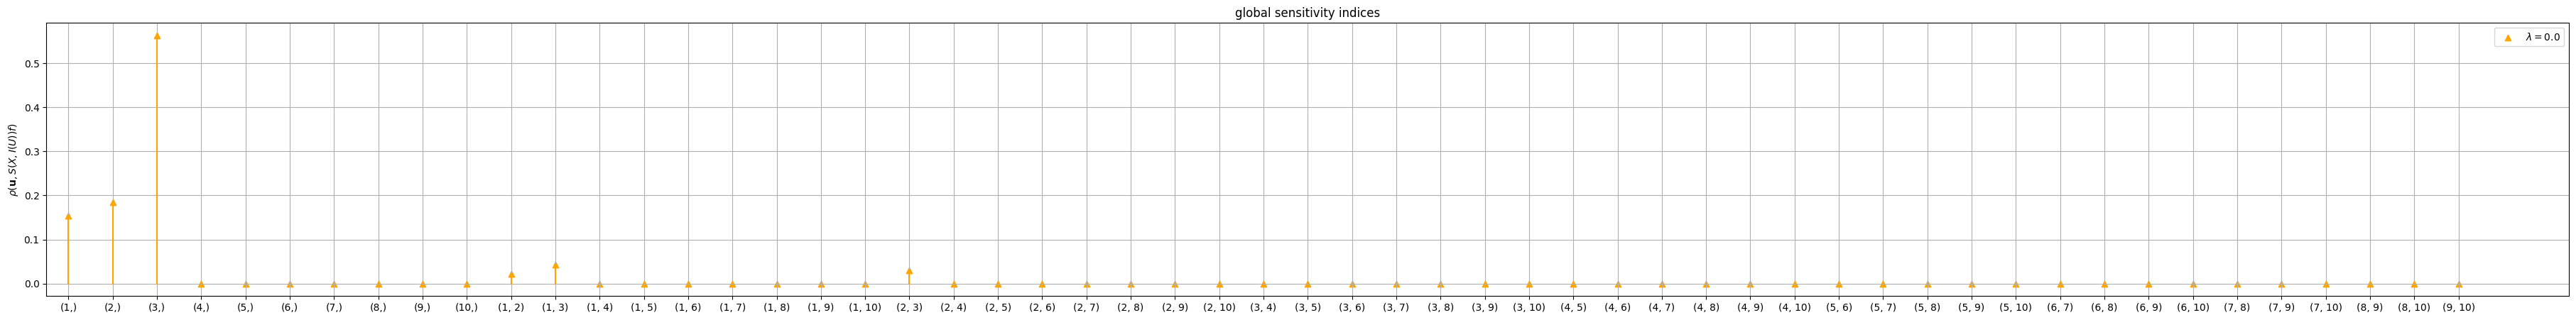

In [70]:
gsis = ads.get_GSI()

if len(lambdas) <= 5:
    colors = [ "orange", "green", "red", "blue", "purple" ]

    #creating raw plot
    fig, ax2 = plt.subplots(1,1)

    #plotting gsis
    #array for xaxis
    xaxis = np.arange(0, len(gsis[lambdas[0]]),1)

    #plotting the gsis
    for l in range(len(lambdas)):
        ax2.scatter(xaxis + 0.15*l, gsis[lambdas[l]], c = colors[l], marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in range(len(xaxis)):
            ax2.plot([i + 0.15*l,i + 0.15*l],[0,gsis[lambdas[l]][i]], c = colors[l])
    
    ax2.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
    ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
    ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
    ax2.set_title("global sensitivity indices")
    ax2.set_xlim(-0.5, len(gsis[lambdas[0]]) + 1.5)
    ax2.legend()
    ax2.grid()
    
    fig.set_figwidth(xaxis.shape[0]/1.2)
    fig.set_figheight(5)
    plt.show()
else:
    for l in range(len(lambdas)):
        color = colors[l % 5]
        #creating raw plot
        fig, ax2 = plt.subplots(1,1)

        #plotting gsis
        #array for xaxis
        xaxis = np.arange(0, len(ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])) - 1,1)

        #plotting gsis
        ax2.scatter(xaxis, gsis[lambdas[l]], c = color, marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in xaxis:
            ax2.plot([i,i],[0,gsis[lambdas[l]][i]], c = color)
        
        ax2.set_xticks(xaxis)
        ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
        ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
        ax2.set_title("global sensitivity indices  $( \\lambda = $" + str(lambdas[l]) + "$)$")
        ax2.legend()

        fig.set_figwidth(xaxis.shape[0]/1.2)
        plt.show()

In the following code cell, you can choose an epsilon for cut off, e.g. ```epsilon = 0.1```. If you don't want to choose an epsilon, we will proceed by taking the mean of all gsis:
$$\varepsilon = \left( \frac{1}{\left| U_{d_s} \right|} \sum_{\mathbf{u} \in U_{d_s}} \rho(\mathbf{u}, S(X, I(U)) f) \right) \cdot \mathbb{1},$$
where $\mathbb{1}$ is the all-one vector of dimension $d_s$.

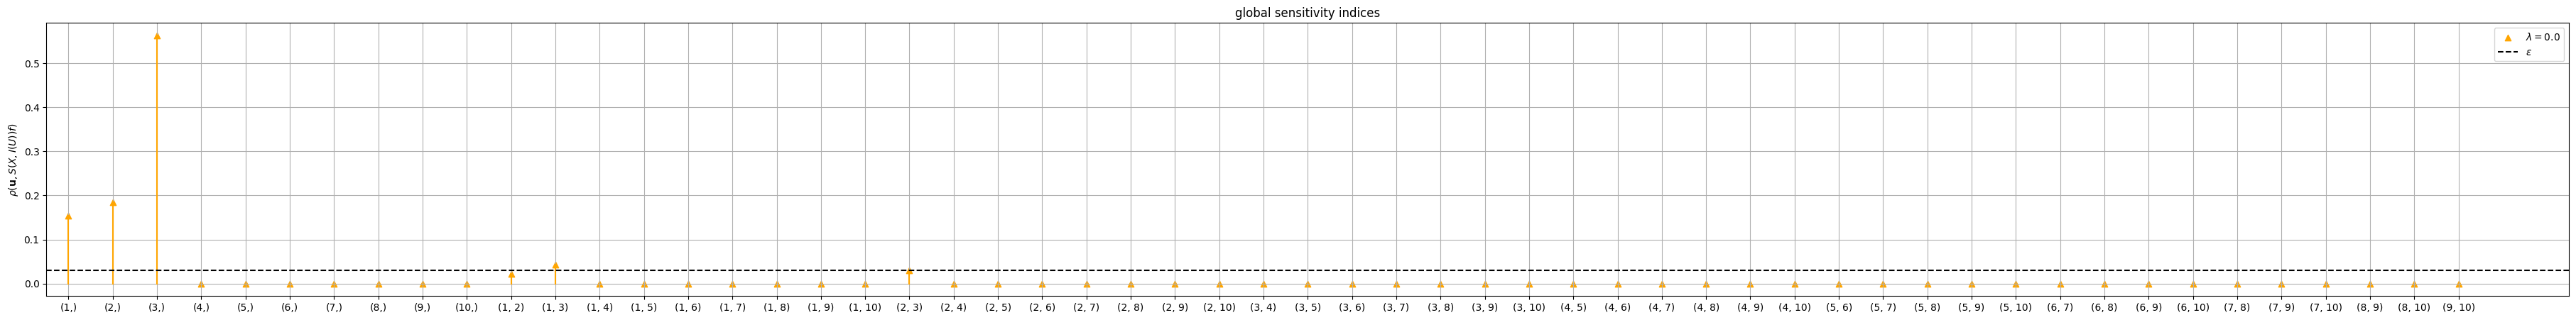

Our new U is [(), (0,), (1,), (2,), (0, 2), (1, 2)].


In [74]:
#choosing an epsilon for cut off
epsilon = 0.03


if epsilon == None:
    epsilon = np.min([np.mean(ads.get_GSI(lam = l)) for l in lambdas])
lambdamin = np.argmin([np.mean(ads.get_GSI(lam = l)) for l in lambdas])


#cutting off all dimensions with GSI less than epsilon
U = ads.get_ActiveSet(np.full((ds),epsilon), lam = lambdas[lambdamin])


#printing gsis with epsilon
if len(lambdas) <= 5:
    colors = [ "orange", "green", "red", "blue", "purple" ]

    #creating raw plot
    fig, ax2 = plt.subplots(1,1)

    #plotting gsis
    #array for xaxis
    xaxis = np.arange(0, len(gsis[lambdas[0]]),1)

    #plotting the gsis
    for l in range(len(lambdas)):
        ax2.scatter(xaxis + 0.15*l, gsis[lambdas[l]], c = colors[l], marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in range(len(xaxis)):
            ax2.plot([i + 0.15*l,i + 0.15*l],[0,gsis[lambdas[l]][i]], c = colors[l])
    ax2.plot([-0.5, len(gsis[lambdas[0]]) + 1.5], [epsilon, epsilon], color = "black", linestyle = "--", label = "$\\varepsilon$")
    ax2.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
    ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
    ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
    ax2.set_title("global sensitivity indices")
    ax2.set_xlim(-0.5, len(gsis[lambdas[0]]) + 1.5)
    ax2.legend()
    ax2.grid()
    
    fig.set_figwidth(xaxis.shape[0]/1.2)
    fig.set_figheight(5)
    plt.show()
else:
    for l in range(len(lambdas)):
        color = colors[l % 5]
        #creating raw plot
        fig, ax2 = plt.subplots(1,1)

        #plotting gsis
        #array for xaxis
        xaxis = np.arange(0, len(ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])) - 1,1)

        #plotting gsis
        ax2.scatter(xaxis, gsis[lambdas[l]], c = color, marker = "^", label = "$\\lambda = $" + str(lambdas[l]))
        for i in xaxis:
            ax2.plot([i,i],[0,gsis[lambdas[l]][i]], c = color)
        
        ax2.set_xticks(xaxis)
        ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
        ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
        ax2.set_title("global sensitivity indices  $( \\lambda = $" + str(lambdas[l]) + "$)$")
        ax2.legend()

        fig.set_figwidth(xaxis.shape[0]/1.2)
        plt.show()

print("Our new U is " + str(U) + ".")

With the information gained trough the atribute ranking and the gsis we have determined a new $U$. We now run the new approximation with automatic bandwidth detection in comparison to the previous approximation again. For that, we use the training data, all of the lambdas, the same basis as before and our newly found $U$. We will also use the same bandwidths as before for the "old" approximation method.

For the autoapproximation of bandwidths the use can set a maximum number of iterations, the approximation will go trough. Therefore place a number of iterations in the following code cell, e.g. ```maxiter = 3```. If you don't wish to set a maximum number of iterations, we will use five iterations. So place ```maxiter = None``` instead of a number.

In [75]:
#choose maximum number of iterations for autoapproximation
maxiter = 2


if maxiter == None:
    maxiter = 5

Now, we run both methods.

In [76]:
#approximation without automatic bandwidth detection
ads = ANOVAapprox.approx(np.transpose(X_train), y_train, lam = lambdas, U = U, N = bw, basis = "cos")
ANOVAapprox.approx.approximate(ads)


#approximation with automatic bandwidth detection
ads_auto = ANOVAapprox.approx(np.transpose(X_train), y_train, lam = lambdas, U = U, basis = "cos")
ANOVAapprox.approx.autoapproximate(ads_auto, maxiter = maxiter, verbosity = 1)

===== Iteration  1  =====
bw in () : []
bw in (0,) : [38]
bw in (1,) : [38]
bw in (2,) : [38]
bw in (0, 2) : [12, 12]
bw in (1, 2) : [12, 12]

===== Iteration  2  =====
bw in () : []
bw in (0,) : [26]
bw in (1,) : [140]
bw in (2,) : [992]
bw in (0, 2) : [6, 6]
bw in (1, 2) : [6, 6]



### Comparing the results

In the end, we want to compare the results of both approximations. Therefore, we calculate the mean squared error of our model and the test data for both models and all our $\lambda$. We then proceed by choosing the model generated by the $\lambda$ that yields the best result, i.e. the minimal mean squared error:
$$\text{MSE} \left( f_j, \tilde{f}_j \right) = \frac{1}{\left| X_{\text{test}} \right|} \sum_{x \in X_{\text{test}}} \left| f_j(x) - \tilde{f}_j(x) \right|^2.$$
Here $j$ denotes the number of the chosen Friedman function.

In [77]:
#model without automatic bandwidth detection
#calculating mean squared error between our model and the test data
mses = ANOVAapprox.get_mse( ads, X = np.transpose(X_test), y = y_test)

#choosing lambda with the least mse among all lambdas
#only important, if multiple lambdas are given
min_index = list(mses.keys())[np.argmin(list(mses.values()))]
err_mse = mses[min_index]


#model with automatic bandwidth detection
#calculating mean squared error between our model and the test data
mses_auto = ANOVAapprox.get_mse( ads_auto, X = np.transpose(X_test), y = y_test)

#choosing lambda with the least mse among all lambdas
#only important, if multiple lambdas are given
min_index_auto = np.argmin(list(mses_auto.values()))
err_mse_auto = mses_auto[min_index_auto]

Now, we compare both models by their errors. We will also have a look on the final attribute ranking and gsis.

At first, let's have a look on the errors given by each $\lambda$. We plot the error on the $y$-axis and the $\lambda$ on the $x$-axis. If only one $\lambda$ is given, then we will skip this part.

In [81]:
if len(lambdas) > 1:
    fig, (ax1, ax2) = plt.subplots(2,1)

    #plotting errors of model without automatic bandwidth detection
    ax1.scatter(lambdas, list(mses.values()), color = "orange")
    for a in range(len(lambdas)):
        ax1.plot([lambdas[a], lambdas[a]], [ err_mse, mses[lambdas[a]]], color = "orange")
    ax1.scatter(min_index, err_mse, color = "green", label = "$\\lambda_{\\min}$")

    ax1.set_xlabel("$\\lambda$")
    ax1.set_ylabel("mse")
    ax1.set_title("errors of model without automatic bandwidth detection")
    ax1.legend()



    #plotting errors of model with automatic bandwidth detection
    ax2.scatter(lambdas, list(mses_auto.values()), color = "orange")
    for a in range(len(lambdas)):
        ax2.plot([lambdas[a], lambdas[a]], [ err_mse_auto, mses_auto[lambdas[a]]], color = "orange")
    ax2.scatter(min_index, err_mse, color = "green", label = "$\\lambda_{\\min}$")
    
    ax2.set_xlabel("$\\lambda$")
    ax2.set_ylabel("mse")
    ax2.set_title("errors of model with automatic bandwidth detection")
    ax2.legend()


    
    fig.subplots_adjust(hspace=0.4)
    plt.show()


print("Without automatic bandwidth detection lambda = " + str(min_index) + " yields the best model with a mean squared error of " + str(err_mse) + ".")
print("With automatic bandwidth detection lambda = " + str(min_index_auto) + " yields the best model with a mean squared error of " + str(err_mse_auto) + ".")
print("=====================================================================================================================================================")

print(err_mse_auto/err_mse)
difference = err_mse - err_mse_auto

if difference < 0:
    print("The model without automatic bandwidth detection has an mse smaller than the mse with automatic bandwidth detection.")
    print("The difference between the two models is", difference, ", so the Model without automatic bandwidth detection has performed better.")
else:
    print("The model with automatic bandwidth detection has an mse smaller than the mse without automatic bandwidth detection.")
    print("The difference between the two models is", difference, ", so the Model with automatic bandwidth detection has performed better.")

Without automatic bandwidth detection lambda = 0.0 yields the best model with a mean squared error of 0.3221494743101145.
With automatic bandwidth detection lambda = 0 yields the best model with a mean squared error of 0.3075220778199651.
0.9545943803835966
The model with automatic bandwidth detection has an mse smaller than the mse without automatic bandwidth detection.
The difference between the two models is 0.01462739649014938 , so the Model with automatic bandwidth detection has performed better.


The following code lets you plot the attribute ranking and gsis only for the two $\lambda$ that minimize the mean squared error for each model.

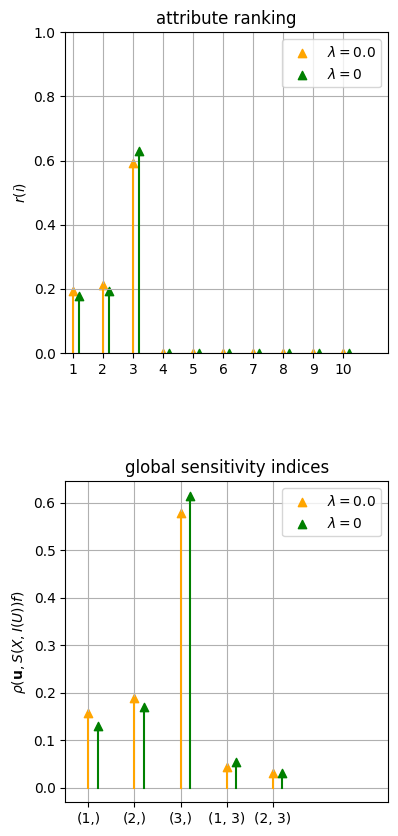

In [80]:
ri = ads.get_AttributeRanking()
gsis = ads.get_GSI()
ri_auto = ads_auto.get_AttributeRanking()
gsis_auto = ads_auto.get_GSI()




#creating raw plot
fig, (ax1, ax2) = plt.subplots(2,1)



#plotting attribute ranking
#array for xaxis
xaxis = np.arange(1, dimensions + 1, 1)

#plotting the attribute ranking
ax1.scatter(xaxis, ri[min_index], c = "orange", marker = "^", label = "$\\lambda = $" + str(min_index))
ax1.scatter(xaxis + 0.2, ri_auto[min_index_auto], c = "green", marker = "^", label = "$\\lambda = $" + str(min_index_auto))
for i in range(len(xaxis)):
    ax1.plot([i + 1,i + 1],[0,ri[min_index][i]], c = "orange")
    ax1.plot([i + 1.2,i + 1.2],[0,ri_auto[min_index_auto][i]], c = "green")

ax1.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
ax1.set_xticklabels(xaxis)
ax1.set_ylabel("$r(i)$")
ax1.set_title("attribute ranking")
ax1.set_xlim(0.75, len(ri[lambdas[0]]) + 1.5)
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid()



#plotting gsis
#array for xaxis
xaxis = np.arange(0, len(gsis[lambdas[0]]),1)

#plotting the gsis
ax2.scatter(xaxis, gsis[min_index], c = "orange", marker = "^", label = "$\\lambda = $" + str(min_index))
ax2.scatter(xaxis + 0.2, gsis_auto[min_index_auto], c = "green", marker = "^", label = "$\\lambda = $" + str(min_index_auto))
for i in range(len(xaxis)):
    ax2.plot([i,i],[0,gsis[min_index][i]], c = "orange")
    ax2.plot([i + 0.2,i + 0.2],[0,gsis_auto[min_index_auto][i]], c = "green")

ax2.set_xticks(xaxis + (len(lambdas) - 1)*0.075)
ax2.set_xticklabels([tuple(x + 1 for x in tup) for tup in ads.get_ActiveSet(np.zeros((ds)), lam = lambdas[0])[1:]])
ax2.set_ylabel("$ \\rho(\\mathbf{u}, S(X, I(U)) f)$")
ax2.set_title("global sensitivity indices")
ax2.set_xlim(-0.5, len(gsis[lambdas[0]]) + 1.5)
ax2.legend()
ax2.grid()


fig.set_figwidth(xaxis.shape[0]/1.2)
fig.set_figheight(10)
fig.subplots_adjust(hspace=0.4)
plt.show()